In [1]:
from utility import load_test_results, architecture_stats

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.min_rows', 5000)
pd.set_option('display.max_rows', 5000)

In [2]:
classifiers_dict, all_results = load_test_results("Classifier_3")

In [3]:
classifiers_dict

{0: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2'])",
 1: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv3', 'FC1'])",
 2: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'Conv3', 'FC1'])",
 3: 'Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=[])',
 4: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv3'])",
 5: 'Classifier_3 (n_neurons_molt_factor=1, do_dropout=[])',
 6: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['FC1'])",
 7: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2', 'Conv3'])",
 8: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['FC1'])",
 9: 'Classifier_3 (n_neurons_molt_factor=2, do_dropout=[])',
 10: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2'])",
 11: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['FC1'])",
 12: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv3'])",
 13: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv3'])",
 14: "Classifier_3 (n_neurons_m

In [4]:
all_results.head(10)

,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,2.0,['Conv2'],0.0005,32,5,0.00,0.020078,0.078545,79.387270
1,0,2.0,['Conv2'],0.0005,32,5,0.25,0.020078,0.078202,94.809957
2,0,2.0,['Conv2'],0.0005,32,5,0.50,0.020078,0.078102,11.220702
3,0,2.0,['Conv2'],0.0005,32,5,0.75,0.020078,0.078387,18.240954
4,0,2.0,['Conv2'],0.0005,32,10,0.00,0.020078,0.077921,0.767154
5,0,2.0,['Conv2'],0.0005,32,10,0.25,0.020078,0.077911,0.947382
6,0,2.0,['Conv2'],0.0005,32,10,0.50,0.020078,0.078122,1.121235
7,0,2.0,['Conv2'],0.0005,32,10,0.75,0.020078,0.078348,1.298127
8,0,2.0,['Conv2'],0.0005,32,15,0.00,0.020078,0.078156,18.438186
9,0,2.0,['Conv2'],0.0005,32,15,0.25,0.020078,0.078327,0.957254


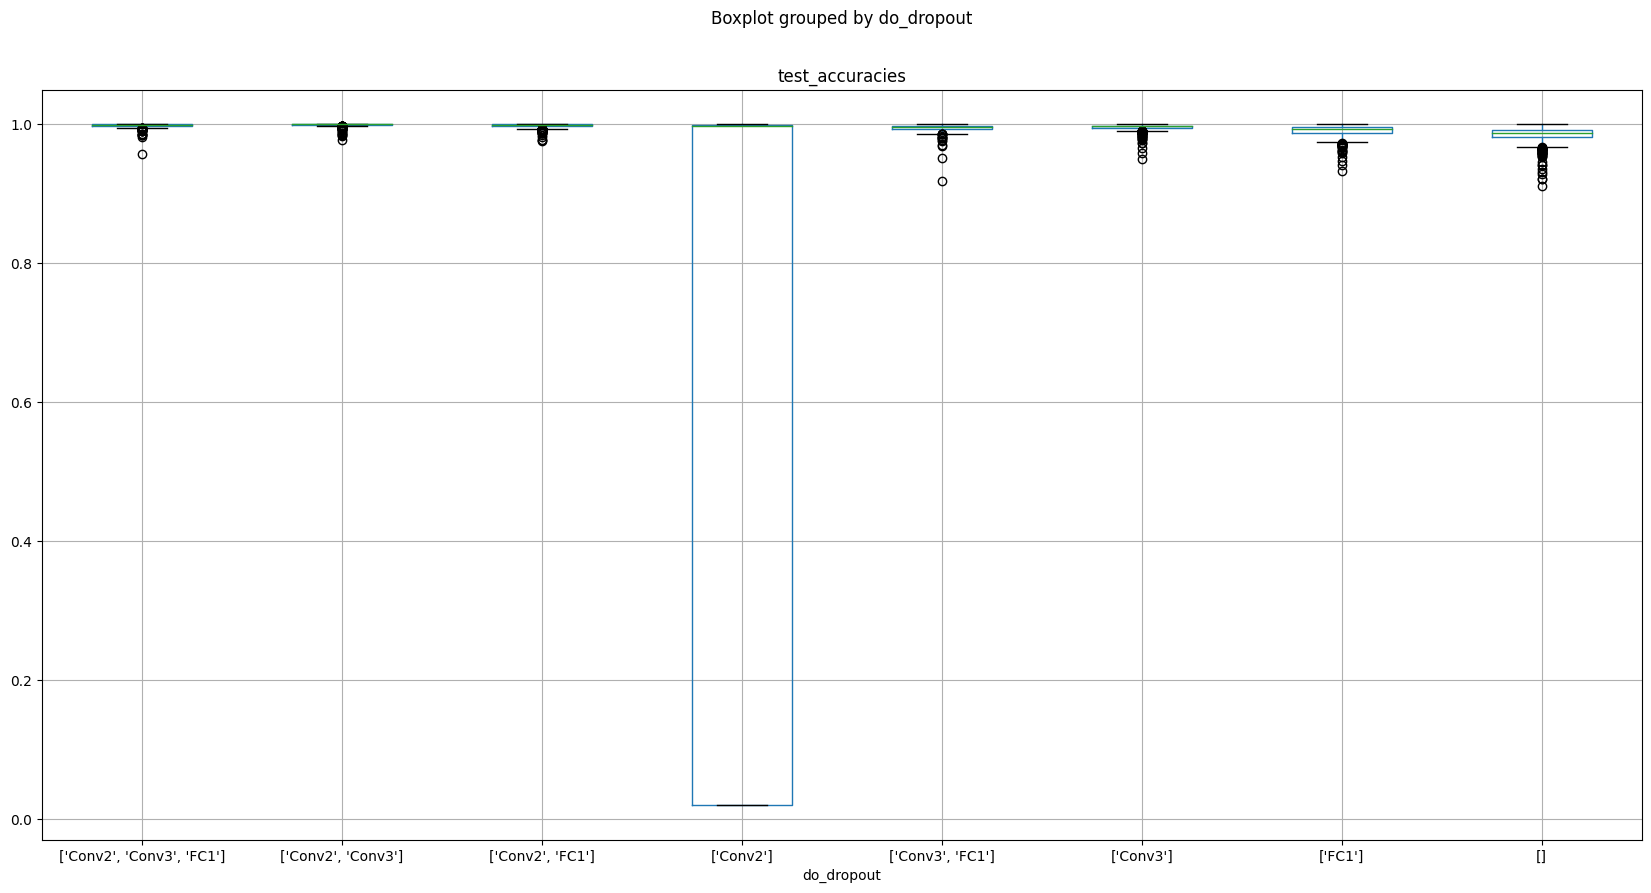

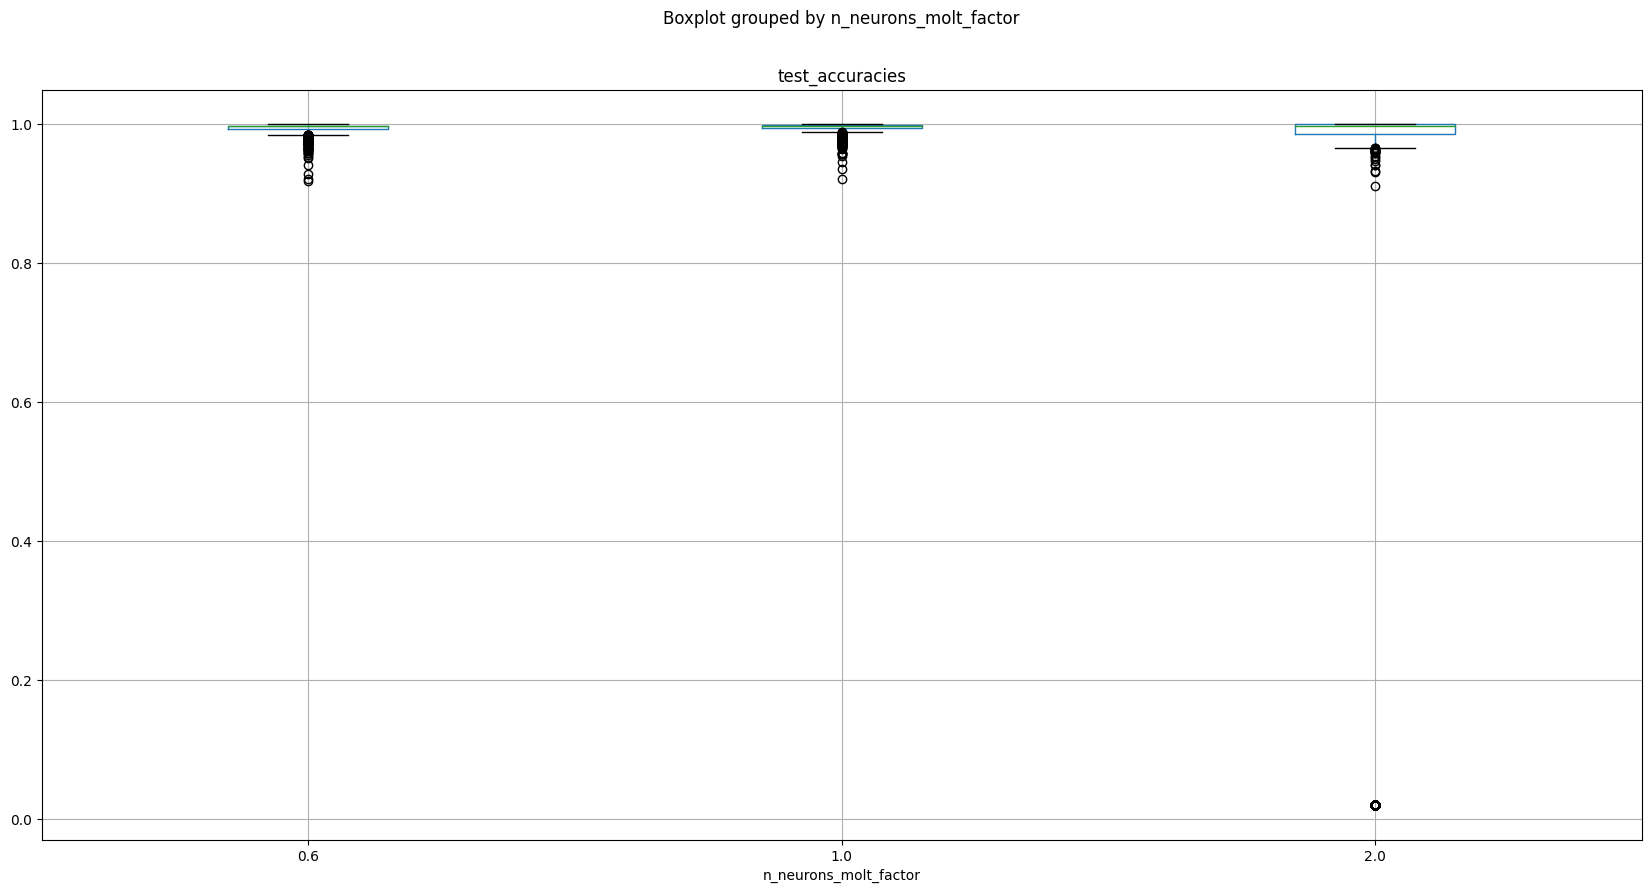

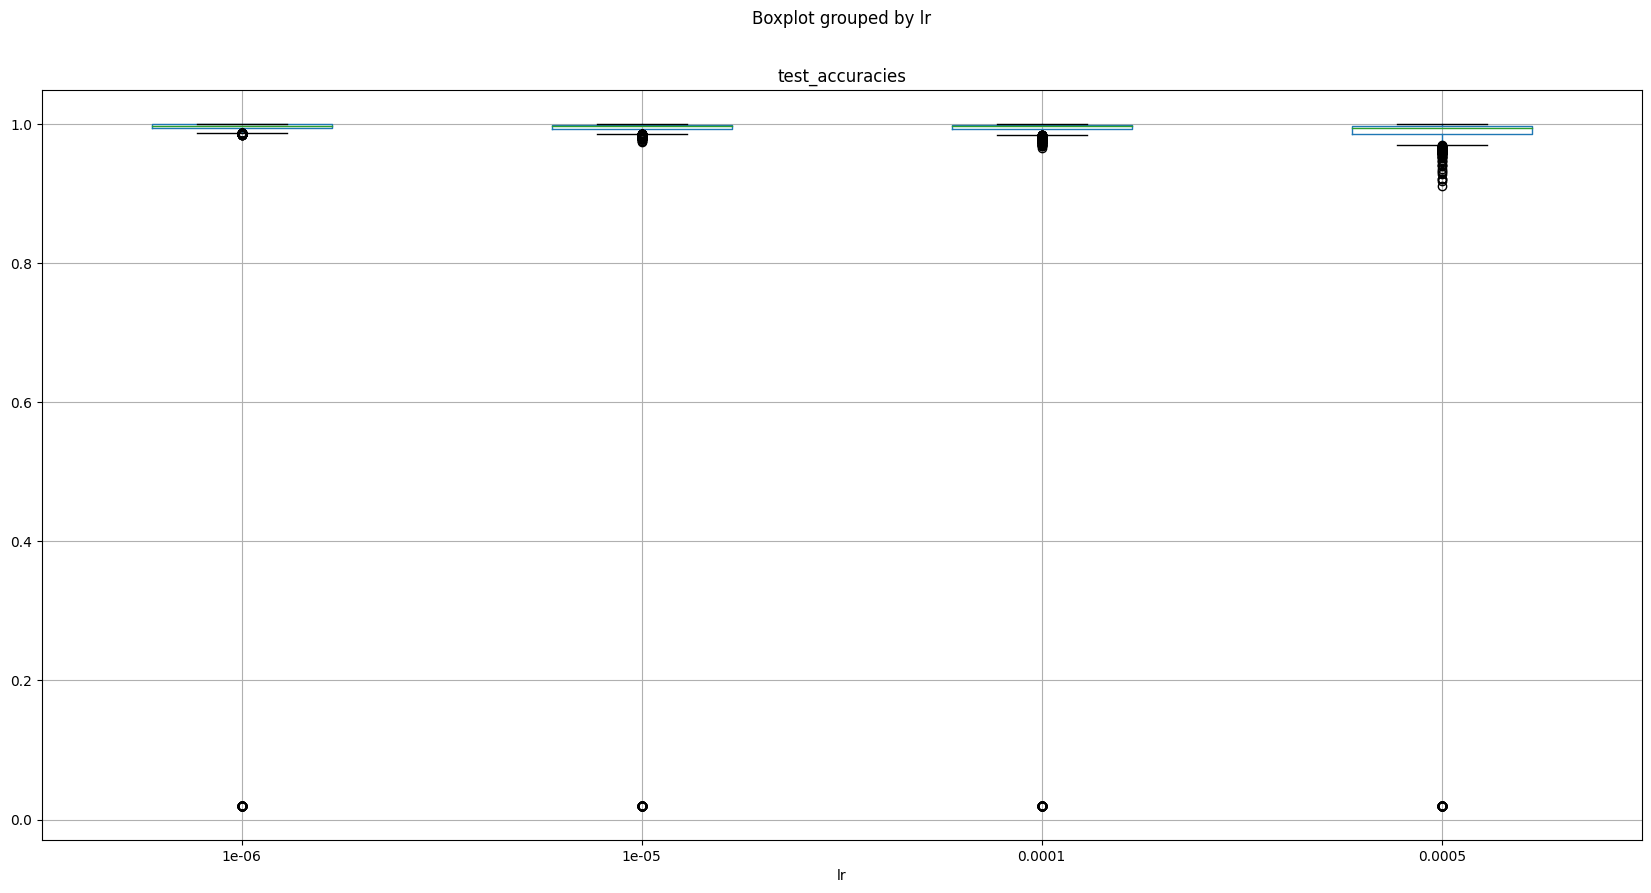

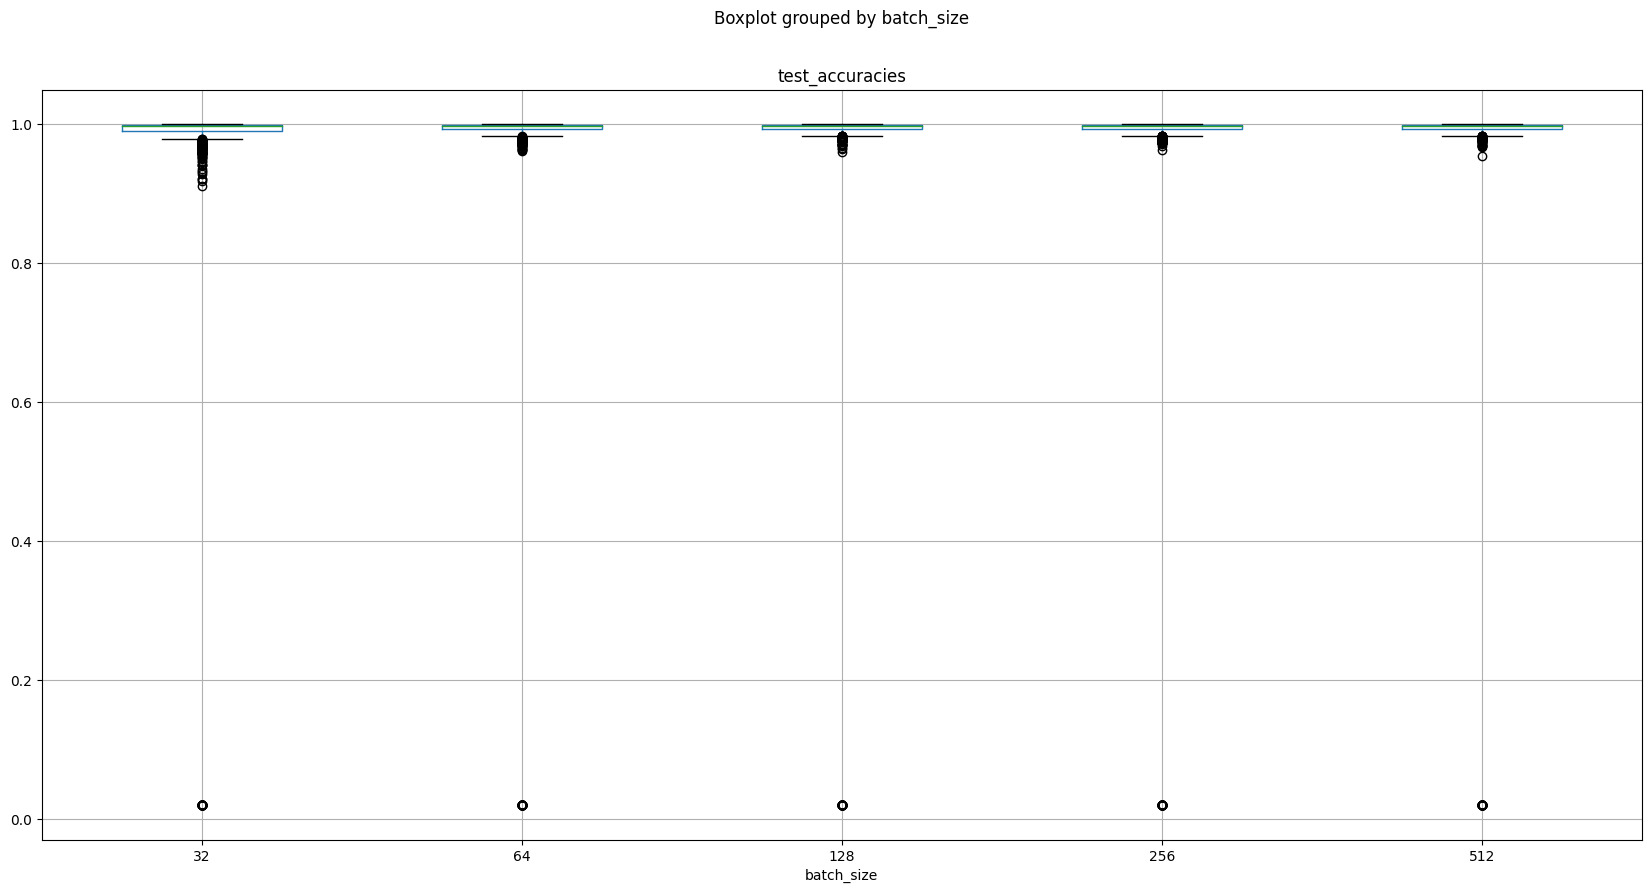

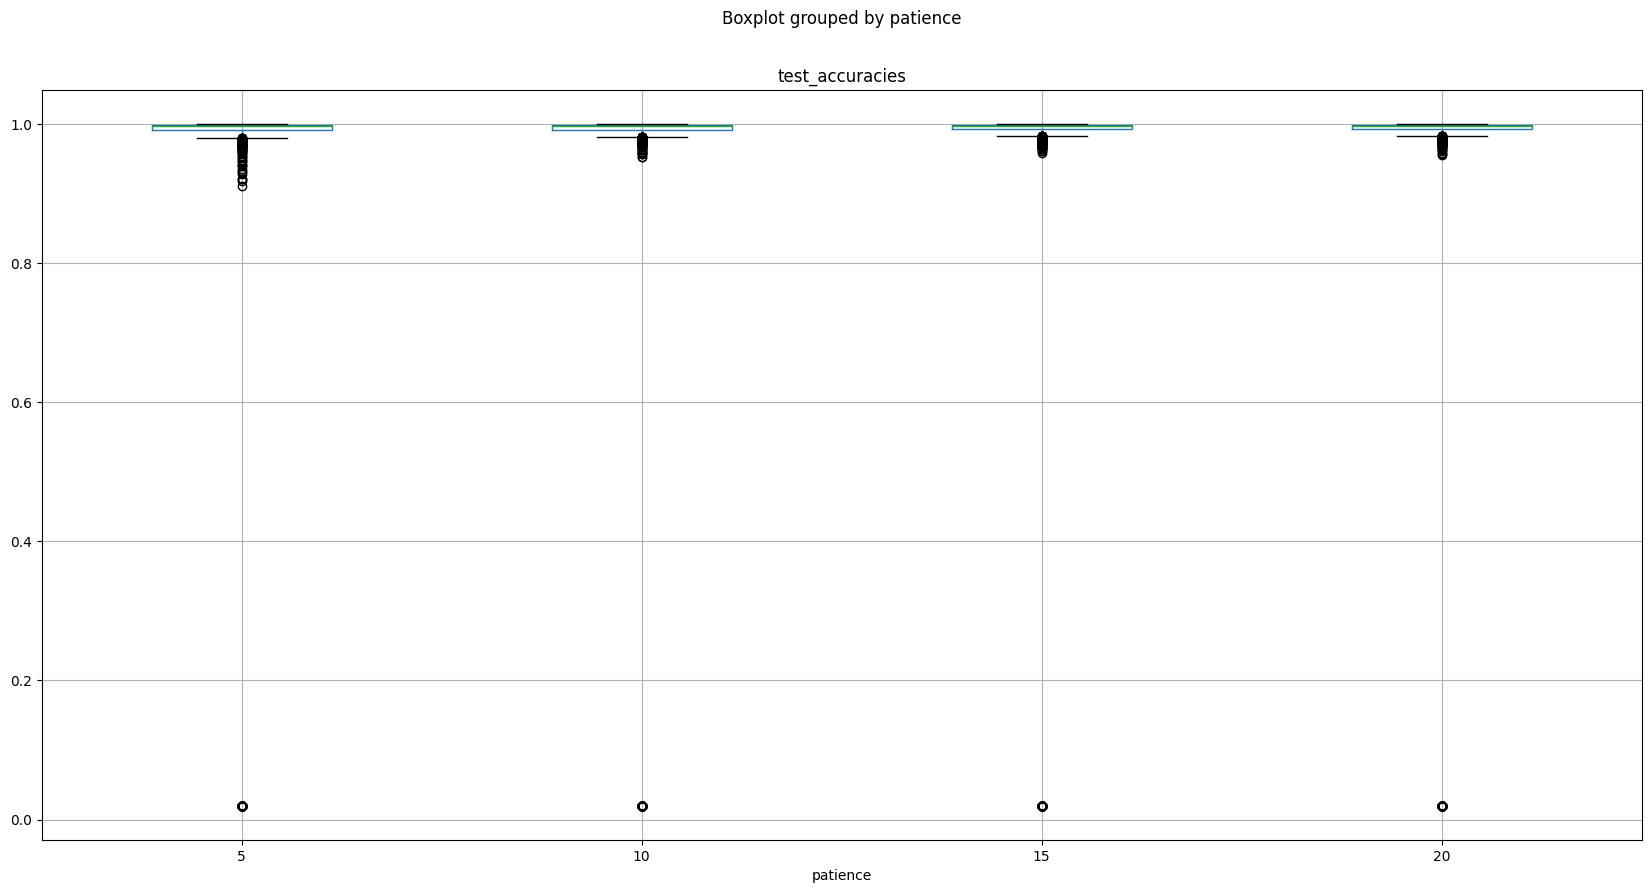

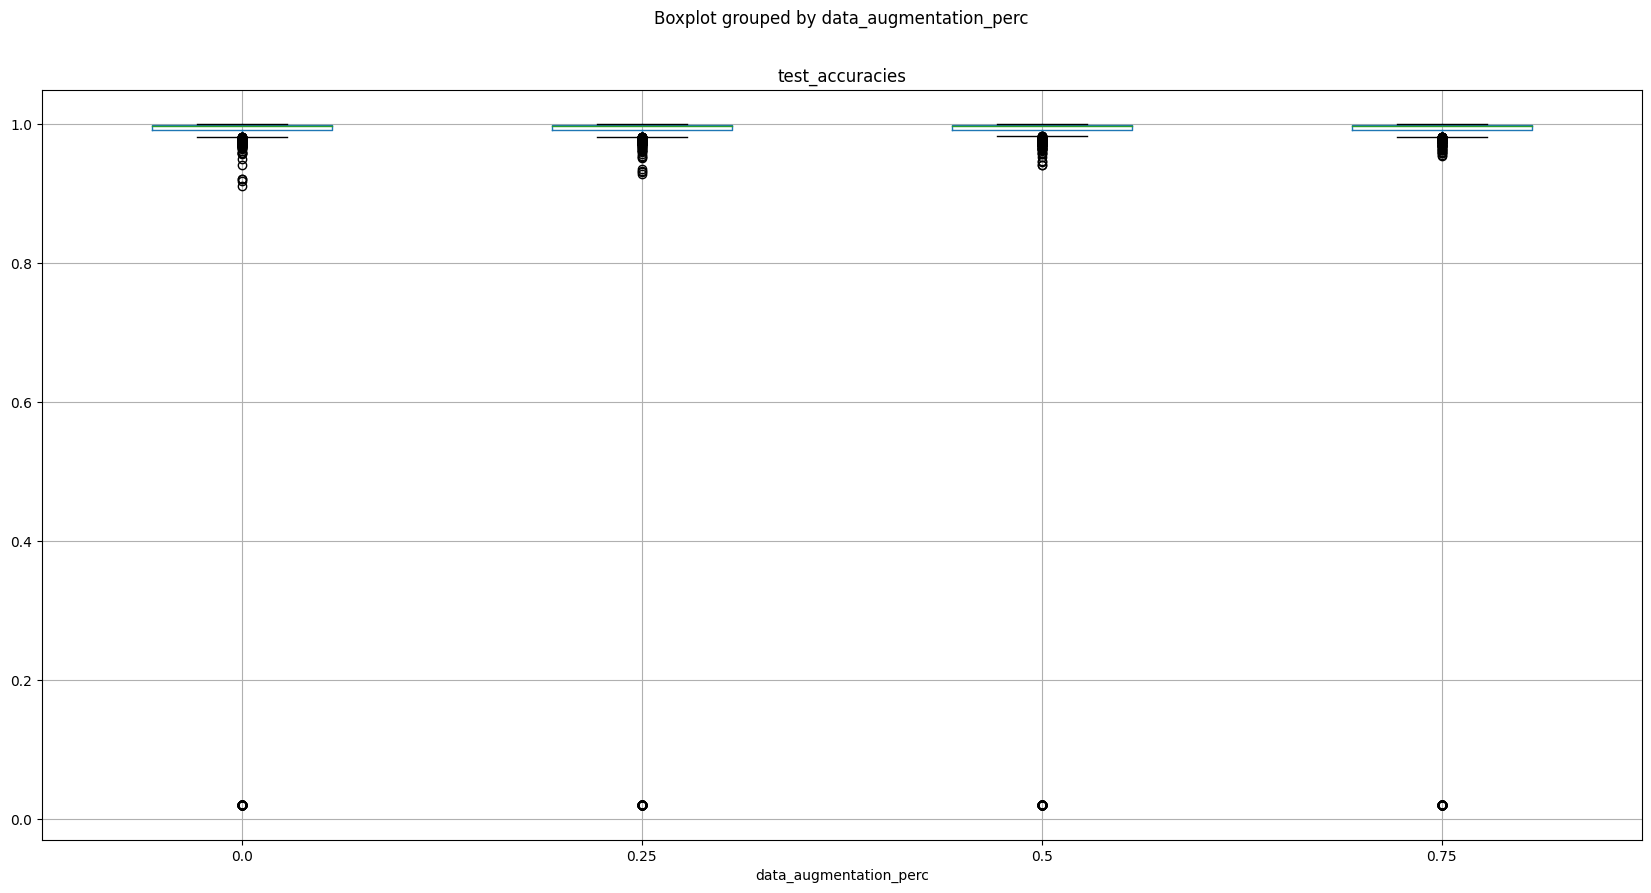

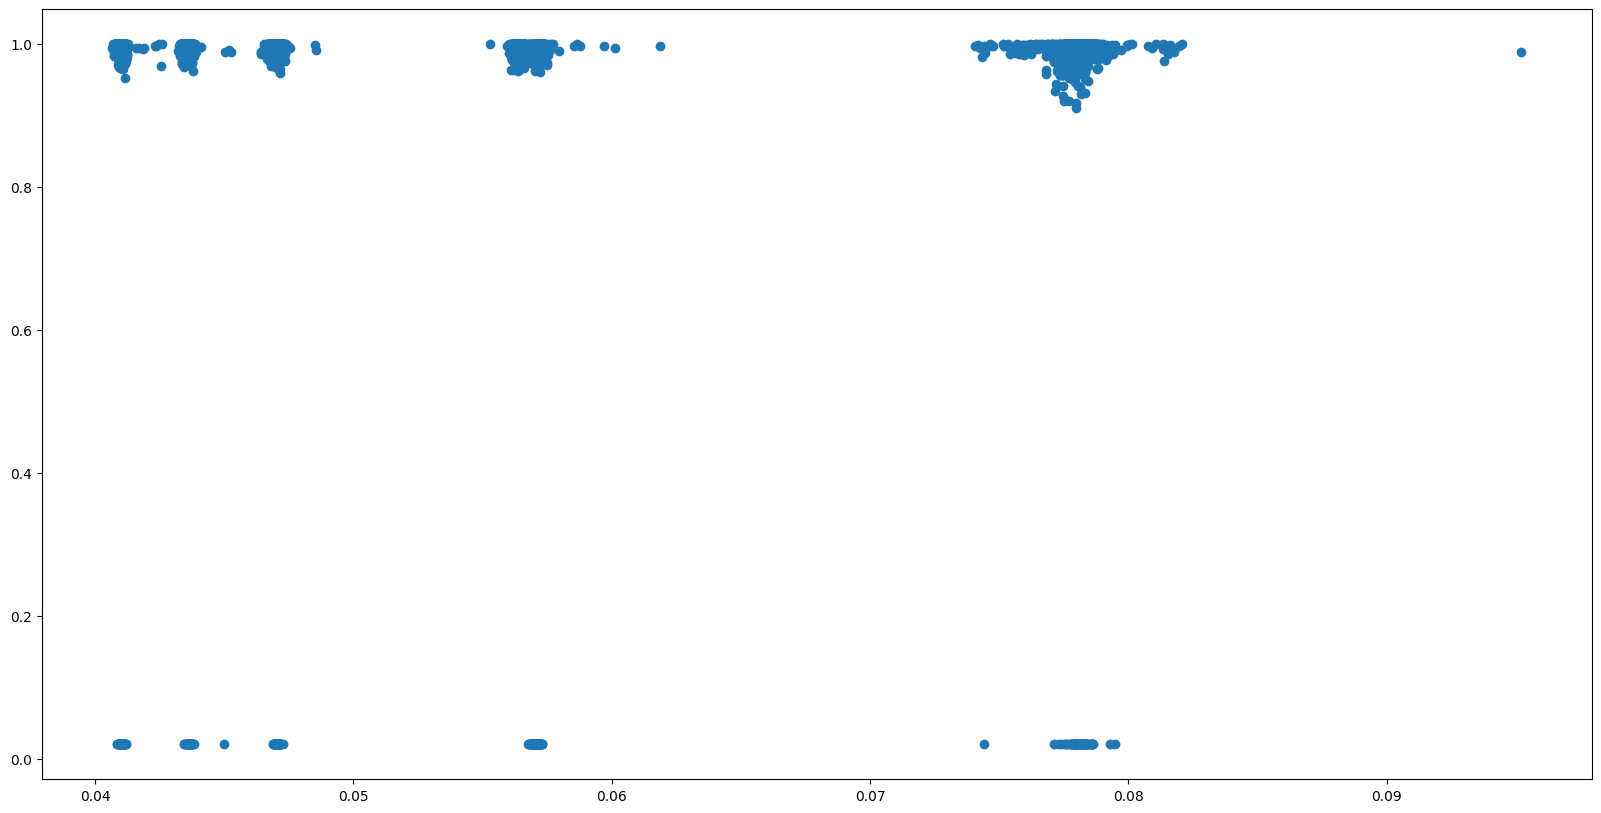

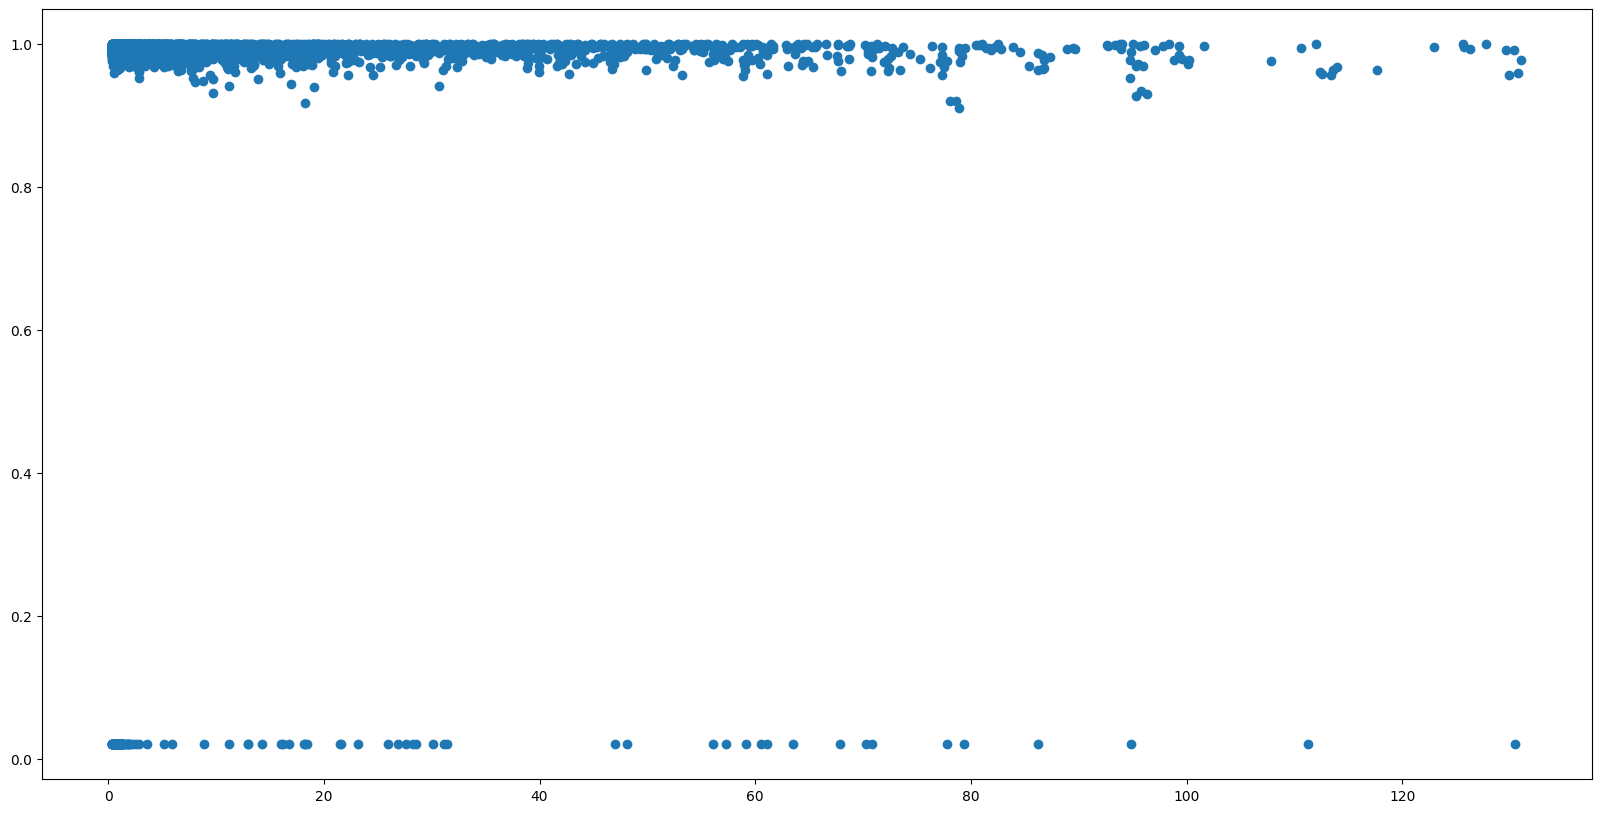

In [5]:
def plot_hyper():
    
    fig,ax=plt.subplots(figsize=(20,10))
    prova = all_results.sort_values(by="do_dropout")
    prova.boxplot(column =["test_accuracies"], by="do_dropout", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="n_neurons_molt_factor", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="lr", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="batch_size", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="patience", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="data_augmentation_perc", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["test_times"], all_results["test_accuracies"])
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["train_times"], all_results["test_accuracies"])

plot_hyper()

In [6]:
all_results.sort_values(by=['test_accuracies'], ascending=False).head(10)

,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
7679,23,2.0,"['Conv2', 'FC1']",0.000001,512,20,0.75,1.0,0.041262,0.645797
6478,20,2.0,"['Conv2', 'Conv3']",0.000500,512,20,0.50,1.0,0.041176,46.007360
6475,20,2.0,"['Conv2', 'Conv3']",0.000500,512,15,0.75,1.0,0.042477,30.053959
6474,20,2.0,"['Conv2', 'Conv3']",0.000500,512,15,0.50,1.0,0.040992,54.516959
6473,20,2.0,"['Conv2', 'Conv3']",0.000500,512,15,0.25,1.0,0.041065,4.798297
6471,20,2.0,"['Conv2', 'Conv3']",0.000500,512,10,0.75,1.0,0.041117,25.479475
6469,20,2.0,"['Conv2', 'Conv3']",0.000500,512,10,0.25,1.0,0.041153,5.737983
6468,20,2.0,"['Conv2', 'Conv3']",0.000500,512,10,0.00,1.0,0.040940,0.764475
6467,20,2.0,"['Conv2', 'Conv3']",0.000500,512,5,0.75,1.0,0.041003,0.645216
6466,20,2.0,"['Conv2', 'Conv3']",0.000500,512,5,0.50,1.0,0.041087,0.557416


In [17]:
n_high_accuracy_models = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].max()])
n_high_accuracy_models

688

In [20]:
high_accuracy_models = all_results.sort_values(by=['test_accuracies'], ascending=False).head(n_high_accuracy_models)["architecture_id"].unique()
high_accuracy_models

array([23, 20, 17, 18,  1,  4,  7,  2, 16, 15, 12, 10, 22, 21])

In [21]:
for model in high_accuracy_models:
    architecture_stats(all_results, classifiers_dict, model)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2', 'FC1']) (id: 23)
mean accuracy: 0.9993 with standard error: 0.0022

worst accuracy: 0.9810 with hyperparameters:
lr                          0.0005
batch_size                      32
patience                        10
data_augmentation_perc        0.25
test_times                0.078145
train_times               1.880124
Name: 7365, dtype: object 

best accuracy: 1.0000 with hyperparameters:
lr                          0.0005
batch_size                      64
patience                        10
data_augmentation_perc         0.5
test_times                0.057163
train_times               3.363832
Name: 7382, dtype: object 

Stats for architecture: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2', 'Conv3']) (id: 20)
mean accuracy: 0.9991 with standard error: 0.0017

worst accuracy: 0.9862 with hyperparameters:
lr                          0.0005
batch_size                      32
patience      

In [22]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(10)

,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,2.0,['Conv2'],0.00050,32,5,0.00,0.020078,0.078545,79.387270
218,0,2.0,['Conv2'],0.00001,256,15,0.50,0.020078,0.043728,0.605537
217,0,2.0,['Conv2'],0.00001,256,15,0.25,0.020078,0.043590,0.510674
216,0,2.0,['Conv2'],0.00001,256,15,0.00,0.020078,0.043718,0.415790
215,0,2.0,['Conv2'],0.00001,256,10,0.75,0.020078,0.043665,70.803141
214,0,2.0,['Conv2'],0.00001,256,10,0.50,0.020078,0.043732,0.606151
213,0,2.0,['Conv2'],0.00001,256,10,0.25,0.020078,0.043670,0.508479
212,0,2.0,['Conv2'],0.00001,256,10,0.00,0.020078,0.043509,0.414539
219,0,2.0,['Conv2'],0.00001,256,15,0.75,0.020078,0.043611,0.735349
211,0,2.0,['Conv2'],0.00001,256,5,0.75,0.020078,0.043459,0.696963


In [23]:
n_low_accuracy_models = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].min()])
n_low_accuracy_models

320

In [24]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(n_low_accuracy_models)["architecture_id"].unique()

array([0])

In [25]:
architecture_stats(all_results, classifiers_dict, 0)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.0201 with standard error: 0.0000

worst accuracy: 0.0201 with hyperparameters:
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc         0.0
test_times                0.078545
train_times               79.38727
Name: 0, dtype: object 

best accuracy: 0.0201 with hyperparameters:
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc         0.0
test_times                0.078545
train_times               79.38727
Name: 0, dtype: object 

